Метод равномерного поиска
 Экстремум на промежутке: [4.385, 4.385] c погрешностью 3.351e-05
 Кол-во итераций: 7
Метод дихотомии
 Экстремум на промежутке: [4.712, 4.712] c погрешностью 3.995e-05
 Кол-во итераций: 16
Метод золотого сечения
 Экстремум на промежутке: [4.712, 4.712] c погрешностью 4.086e-05
 Кол-во итераций: 23
Метод Фибоначчи
 Экстремум на промежутке: [4.712, 4.712] c погрешностью 2.525e-05
 Кол-во итераций: 12


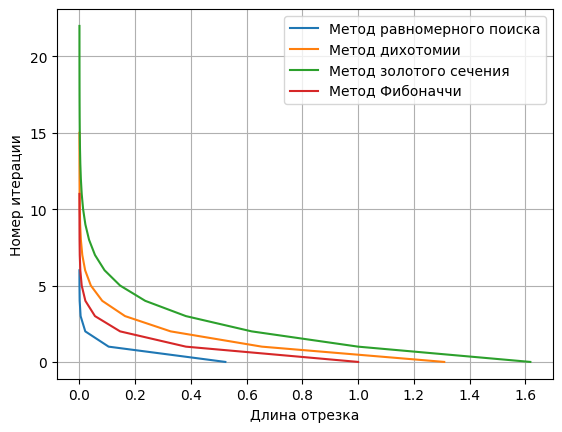

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

PI = np.pi
TAU = 0.5 * (np.sqrt(5) - 1)

eps = 2**(-14)
a = 2 * PI / 3
b = 3 * PI / 2


def f(x) -> float:
    return np.sin(x - PI / 2)


def f_list(x) -> list[float]:
    result = []
    for i in x:
        result.append(f(i))
    return result


def float_output(x) -> str:
    return f"{float(x):.4}"


def beauty_output(func):
    def wrapper(*args, **kwargs):
        start, end, result, N = func(*args, **kwargs)
        return (
            float_output(start),
            float_output(end),
            result,
            N,
    )
    return wrapper


@beauty_output
def uniform_search(start, end, number_of_intervals):
    N = 0
    result = []
    while (abs(end - start) > eps):
        x = np.arange(start, end, (end - start) / number_of_intervals)
        values = f_list(x)
        # Ищем интервал, где f(x) min
        min_index = max(1, min(values.index(min(values)), len(x) - 2))
        start, end = x[min_index - 1], x[min_index + 1]
        N += 1
        result.append(end - start)
    return (start, end, result, N)


@beauty_output
def dichotomy_search(start, end):
    N = 0
    result = []
    while (abs(end - start) > eps):
        n = (start + end) / 2
        x = [(start + n) / 2, (end + n) / 2]
        values = f_list(x)
        (end, start) = (n, start) if values[0] < values[1] else (end, n)
        N += 1
        result.append(end - start)
    return (start, end, result, N)


@beauty_output
def golden_ratio(start, end):
    N = 0
    result = []
    while (abs(end - start) > eps):
        x = [end - (end - start) * TAU, start + (end - start) * TAU]
        values = f_list(x)
        if values[0] < values[1]:
            end = x[1]
        else:
            start = x[0]
        N += 1
        result.append(end-start)
    return (start, end, result, N)


@beauty_output
def fibonachi(start, end):
    N = 1
    result = []
    fib = [1, 1]
    while ((end - start) / fib[-1] > eps):
        fib.append(fib[-2] + fib[-1])
    while (abs(end - start) > eps):
        x = [start + (end - start) * (fib[len(fib) - 1 - N] / fib[len(fib) - N]), 
            start + (end - start) * (fib[len(fib) - 1 -  N] / fib[len(fib) - N])]
        # Если x одинаковы, то добавить небольшую разницу
        if x[0] == x[1]: 
            x[1] += (end - start) / 10
        values = f_list(x)
        if values[1] < values[0]:
            start = x[0]
        else:
            end = x[1]
        N += 1
        result.append(end - start)
    return (start, end, result, N - 1)


def report_and_plot(method_name, search_result, plot=True):
    start, end, result, N = search_result
    print(f"{method_name}\n"
          f" Экстремум на промежутке: [{start}, {end}] "
          f"c погрешностью {result[-1]:.3e}\n"
          f" Кол-во итераций: {N}")
    if plot:
        plt.plot(result, range(N), label=method_name)


def plots():
    report_and_plot("Метод равномерного поиска", uniform_search(a, b, 5))
    report_and_plot("Метод дихотомии",           dichotomy_search(a, b))
    report_and_plot("Метод золотого сечения",    golden_ratio(a, b))
    report_and_plot("Метод Фибоначчи",           fibonachi(a, b))

    plt.xlabel("Длина отрезка")
    plt.ylabel("Номер итерации")
    plt.legend()
    plt.grid(True)


plots()

In [21]:
import pandas as pd

AB = abs(a - b)
N = [8, 12, 16]
methods = ["Метод равномерного поиска", "Метод дихотомии", "Метод золотого сечения", "Метод Фибоначчи"]


def fib(n: int) -> int:
    if n == 0 or n == 1: return n
    return fib(n - 1) + fib (n - 2)


def W(method_name, n: int) -> float:
    match method_name:
        case "Метод равномерного поиска":
            return 2 * AB / (n - 1)
        case "Метод дихотомии":
            return AB / (2 ** (n / 2))
        case "Метод золотого сечения":
            return AB * (TAU ** (n - 1))
        case "Метод Фибоначчи":
            return AB / fib(n - 1)
        case _:
            return 0


def get_w_df() -> pd.DataFrame:
    data = {n: [W(m, n) for m in methods] for n in N}
    df = pd.DataFrame(data, index=methods)
    df.columns.name = "N (число итераций)"
    df.index.name = "Метод"
    return df


get_w_df()

N (число итераций),8,12,16
Метод,,,
Метод равномерного поиска,0.747998,0.475999,0.349066
Метод дихотомии,0.163625,0.040906,0.010227
Метод золотого сечения,0.090169,0.013155,0.001919
Метод Фибоначчи,0.201384,0.029416,0.004292
